In [1]:
# ==================== INSTALL & SETUP ====================
# %pip install tensorflow --quiet

# Load preprocessed data and label info
%run CleanData.ipynb

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==================== DATA PREP ====================
# Convert to NumPy arrays if needed
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

# Normalize (if not done in CleanData)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


In [4]:
# ==================== FOCAL LOSS DEFINITION ====================
import tensorflow.keras.backend as K
from tensorflow.keras.losses import Loss

class FocalLoss(Loss):
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = self.alpha * K.pow(1 - y_pred, self.gamma)
        return K.sum(weight * cross_entropy, axis=1)


In [5]:
def build_model(units, learning_rate):
    model = Sequential([
        Conv1D(32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(units, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=FocalLoss(gamma=2.0, alpha=0.5), metrics=['accuracy'])
    return model

In [ ]:
param_sets = [
    {"units": 64, "learning_rate": 0.001},
    {"units": 128, "learning_rate": 0.0005},
    {"units": 256, "learning_rate": 0.0001}
]

histories = []

for params in param_sets:
    print(f"Training with: units={params['units']}, lr={params['learning_rate']}")
    model = build_model(params['units'], params['learning_rate'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train_cat,
        epochs=30,
        batch_size=128,
        validation_data=(X_test, y_test_cat),
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )
    
    label = f"units={params['units']}, lr={params['learning_rate']}"
    histories.append((label, history))


Training with: units=64, lr=0.001


c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with: units=128, lr=0.0005
Training with: units=256, lr=0.0001


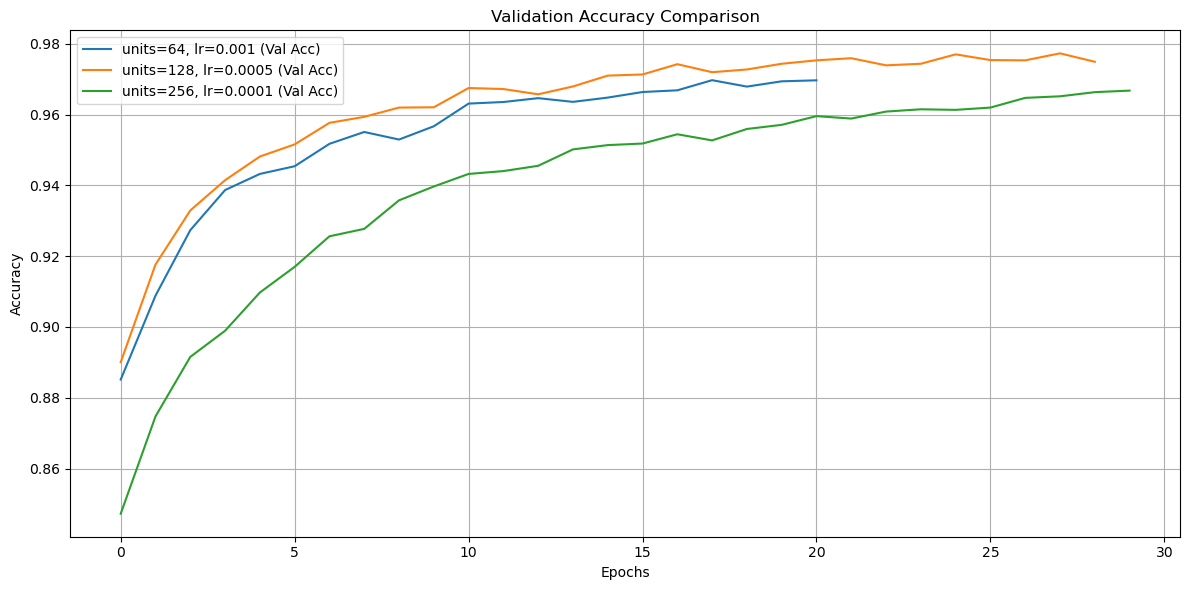

In [7]:
plt.figure(figsize=(12, 6))

# Plot validation accuracy
for label, history in histories:
    plt.plot(history.history['val_accuracy'], label=f"{label} (Val Acc)")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

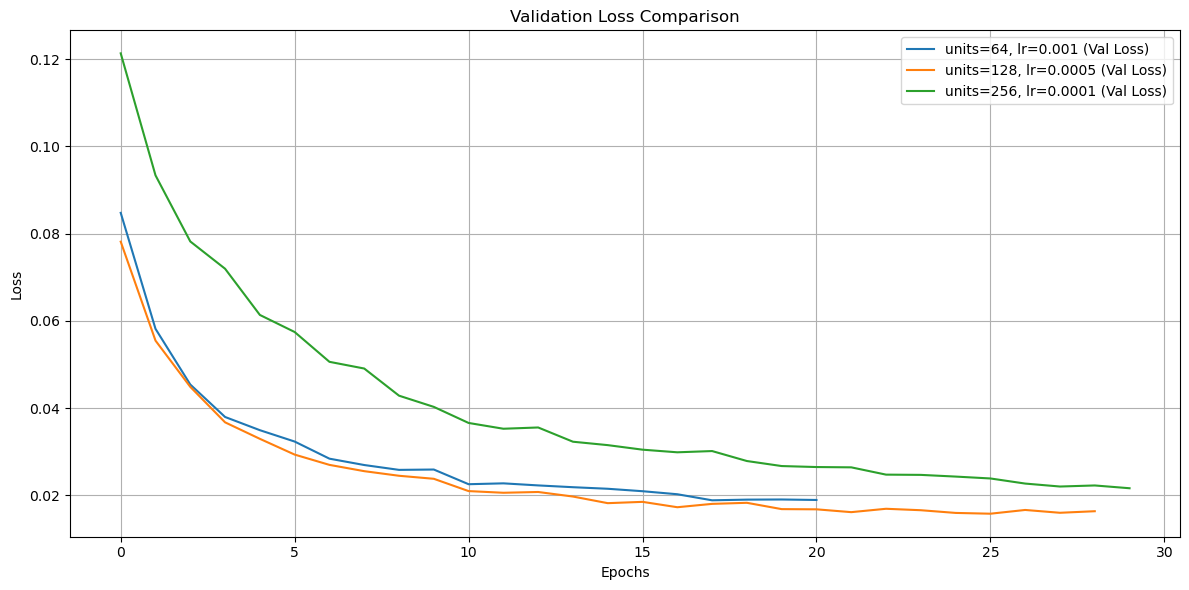

In [8]:
plt.figure(figsize=(12, 6))
for label, history in histories:
    plt.plot(history.history['val_loss'], label=f"{label} (Val Loss)")

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
